# Facial keypoint detection
The following notebook gives the solution for Kaggle project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle



In [2]:
df_train = pd.read_csv("./data/training.csv")
df_test = pd.read_csv("./data/test.csv")


In [3]:
display(df_train.head())


,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


In [4]:
df_train.columns

Index(['left_eye_center_x', 'left_eye_center_y', 'right_eye_center_x',
       'right_eye_center_y', 'left_eye_inner_corner_x',
       'left_eye_inner_corner_y', 'left_eye_outer_corner_x',
       'left_eye_outer_corner_y', 'right_eye_inner_corner_x',
       'right_eye_inner_corner_y', 'right_eye_outer_corner_x',
       'right_eye_outer_corner_y', 'left_eyebrow_inner_end_x',
       'left_eyebrow_inner_end_y', 'left_eyebrow_outer_end_x',
       'left_eyebrow_outer_end_y', 'right_eyebrow_inner_end_x',
       'right_eyebrow_inner_end_y', 'right_eyebrow_outer_end_x',
       'right_eyebrow_outer_end_y', 'nose_tip_x', 'nose_tip_y',
       'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_right_corner_x',
       'mouth_right_corner_y', 'mouth_center_top_lip_x',
       'mouth_center_top_lip_y', 'mouth_center_bottom_lip_x',
       'mouth_center_bottom_lip_y', 'Image'],
      dtype='str')

In [5]:
np.sqrt(np.fromstring(df_train["Image"][8], sep=" ").shape[0])

np.float64(96.0)

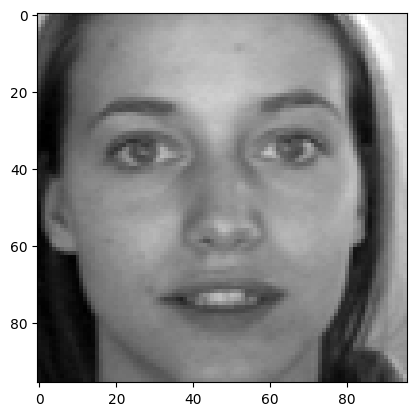

In [6]:
plt.imshow(np.fromstring(df_train["Image"][8], sep=" ").reshape(96, 96), cmap="gray")

In [7]:

FEATURE_COLORS = {
    "eye": "red",
    "eyebrow": "blue",
    "nose": "green",
    "mouth": "yellow"
}


def get_face_with_keypoints(df, image_index):
    image = np.fromstring(df["Image"][image_index], sep=" ").reshape(96, 96)

    keypoints = df.iloc[image_index, :-1].values.astype("float")
    keypoints = keypoints.reshape(-1, 2)

    return image, keypoints


def show_face_with_keypoints(df, image_index):
    image, keypoints = get_face_with_keypoints(df, image_index)

    # Column names except Image
    columns = df.columns[:-1]

    plt.figure(figsize=(8, 8))
    plt.imshow(image, cmap="gray")

    for i in range(0, len(columns), 2):

        x_name = columns[i]
        y_name = columns[i + 1]

        x, y = keypoints[i // 2]

        if np.isnan(x) or np.isnan(y):
            continue

        # Select color based on feature name
        if "eye" in x_name:
            color = FEATURE_COLORS["eye"]
        elif "eyebrow" in x_name:
            color = FEATURE_COLORS["eyebrow"]
        elif "nose" in x_name:
            color = FEATURE_COLORS["nose"]
        elif "mouth" in x_name:
            color = FEATURE_COLORS["mouth"]
        else:
            color = "white"

        # Draw point
        plt.scatter(x, y, color=color, s=10)

        # Add label
        label = x_name.replace("_x", "")
        plt.text(
            x + 1,
            y + 1,
            label,
            color=color,
            fontsize=7
        )

    plt.title(f"Face Keypoints - Image {image_index}")
    plt.axis("off")
    plt.show()

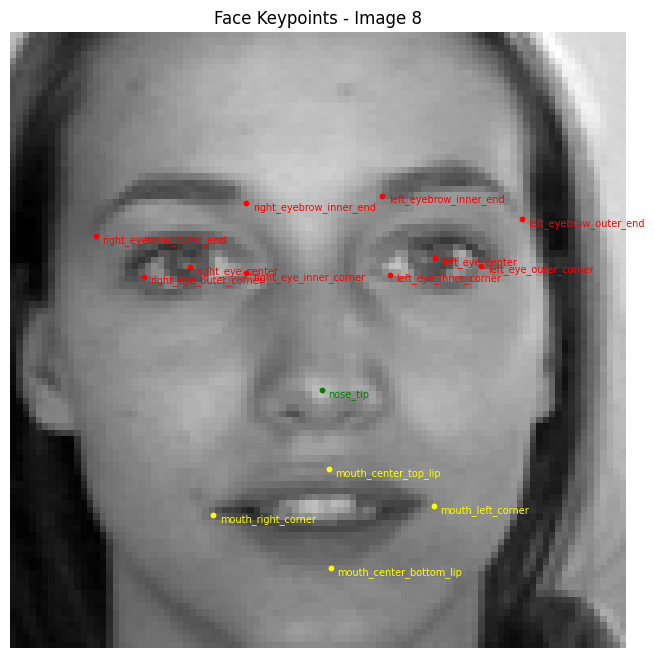

In [8]:
show_face_with_keypoints(df_train, 8)

## Image Preprocessing

In [9]:
len(df_train)

7049

In [10]:
df_train.isnull().sum()

left_eye_center_x              10
left_eye_center_y              10
right_eye_center_x             13
right_eye_center_y             13
left_eye_inner_corner_x      4778
left_eye_inner_corner_y      4778
left_eye_outer_corner_x      4782
left_eye_outer_corner_y      4782
right_eye_inner_corner_x     4781
right_eye_inner_corner_y     4781
right_eye_outer_corner_x     4781
right_eye_outer_corner_y     4781
left_eyebrow_inner_end_x     4779
left_eyebrow_inner_end_y     4779
left_eyebrow_outer_end_x     4824
left_eyebrow_outer_end_y     4824
right_eyebrow_inner_end_x    4779
right_eyebrow_inner_end_y    4779
right_eyebrow_outer_end_x    4813
right_eyebrow_outer_end_y    4813
nose_tip_x                      0
nose_tip_y                      0
mouth_left_corner_x          4780
mouth_left_corner_y          4780
mouth_right_corner_x         4779
mouth_right_corner_y         4779
mouth_center_top_lip_x       4774
mouth_center_top_lip_y       4774
mouth_center_bottom_lip_x      33
mouth_center_b

In [11]:
df_clean = df_train[df_train.notnull().all(axis=1)]

In [12]:
df_unclean = df_train[~df_train.notnull().all(axis=1)]  

In [13]:
display(df_unclean.head())

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
210,65.365120,39.988480,28.251520,37.399680,59.322880,40.851840,71.982080,41.715200,33.717760,38.550400,...,61.278720,57.884800,87.459200,34.293120,85.157760,46.376960,79.116160,NaN,NaN,181 56 47 59 65 71 86 66 32 22 17 7 8 12 13 14...
350,67.258311,37.229867,26.980267,36.270862,60.225422,37.549511,74.291200,37.549511,34.333156,36.590507,...,62.163911,57.028978,86.778311,36.251022,87.097600,45.201778,79.106133,NaN,NaN,59 41 36 32 32 31 33 41 55 72 79 70 64 50 52 6...
499,65.783008,41.160992,29.971041,37.969983,60.464132,41.160992,71.455736,42.224926,35.289917,39.388562,...,58.180760,56.918479,85.482843,28.197818,81.937190,45.926876,75.554380,NaN,NaN,118 127 122 109 129 154 158 148 147 152 136 13...
512,68.286689,38.490807,31.361311,38.490807,61.604459,39.194125,74.264656,38.842466,35.933115,38.490807,...,59.590820,64.770098,82.800787,33.823475,82.449049,48.241574,71.547541,NaN,NaN,194 194 194 191 194 191 191 183 166 151 126 86...
810,72.376354,37.281897,24.536920,35.003894,64.187469,37.314945,79.589947,39.180234,33.269522,36.142896,...,57.784269,65.161912,83.222655,28.713345,82.463150,47.420602,77.785827,NaN,NaN,124 124 126 128 131 134 136 141 141 139 138 14...


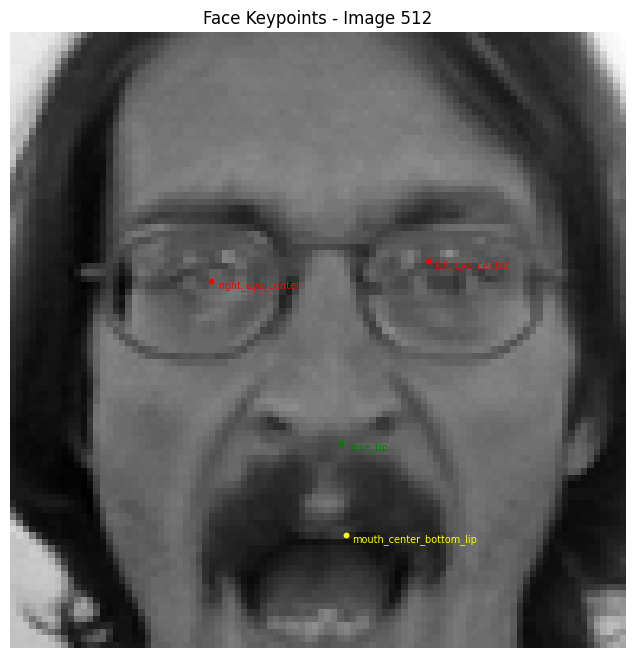

In [14]:
show_face_with_keypoints(df_unclean, 512)

In [15]:
df_clean.isnull().sum()

left_eye_center_x            0
left_eye_center_y            0
right_eye_center_x           0
right_eye_center_y           0
left_eye_inner_corner_x      0
left_eye_inner_corner_y      0
left_eye_outer_corner_x      0
left_eye_outer_corner_y      0
right_eye_inner_corner_x     0
right_eye_inner_corner_y     0
right_eye_outer_corner_x     0
right_eye_outer_corner_y     0
left_eyebrow_inner_end_x     0
left_eyebrow_inner_end_y     0
left_eyebrow_outer_end_x     0
left_eyebrow_outer_end_y     0
right_eyebrow_inner_end_x    0
right_eyebrow_inner_end_y    0
right_eyebrow_outer_end_x    0
right_eyebrow_outer_end_y    0
nose_tip_x                   0
nose_tip_y                   0
mouth_left_corner_x          0
mouth_left_corner_y          0
mouth_right_corner_x         0
mouth_right_corner_y         0
mouth_center_top_lip_x       0
mouth_center_top_lip_y       0
mouth_center_bottom_lip_x    0
mouth_center_bottom_lip_y    0
Image                        0
dtype: int64

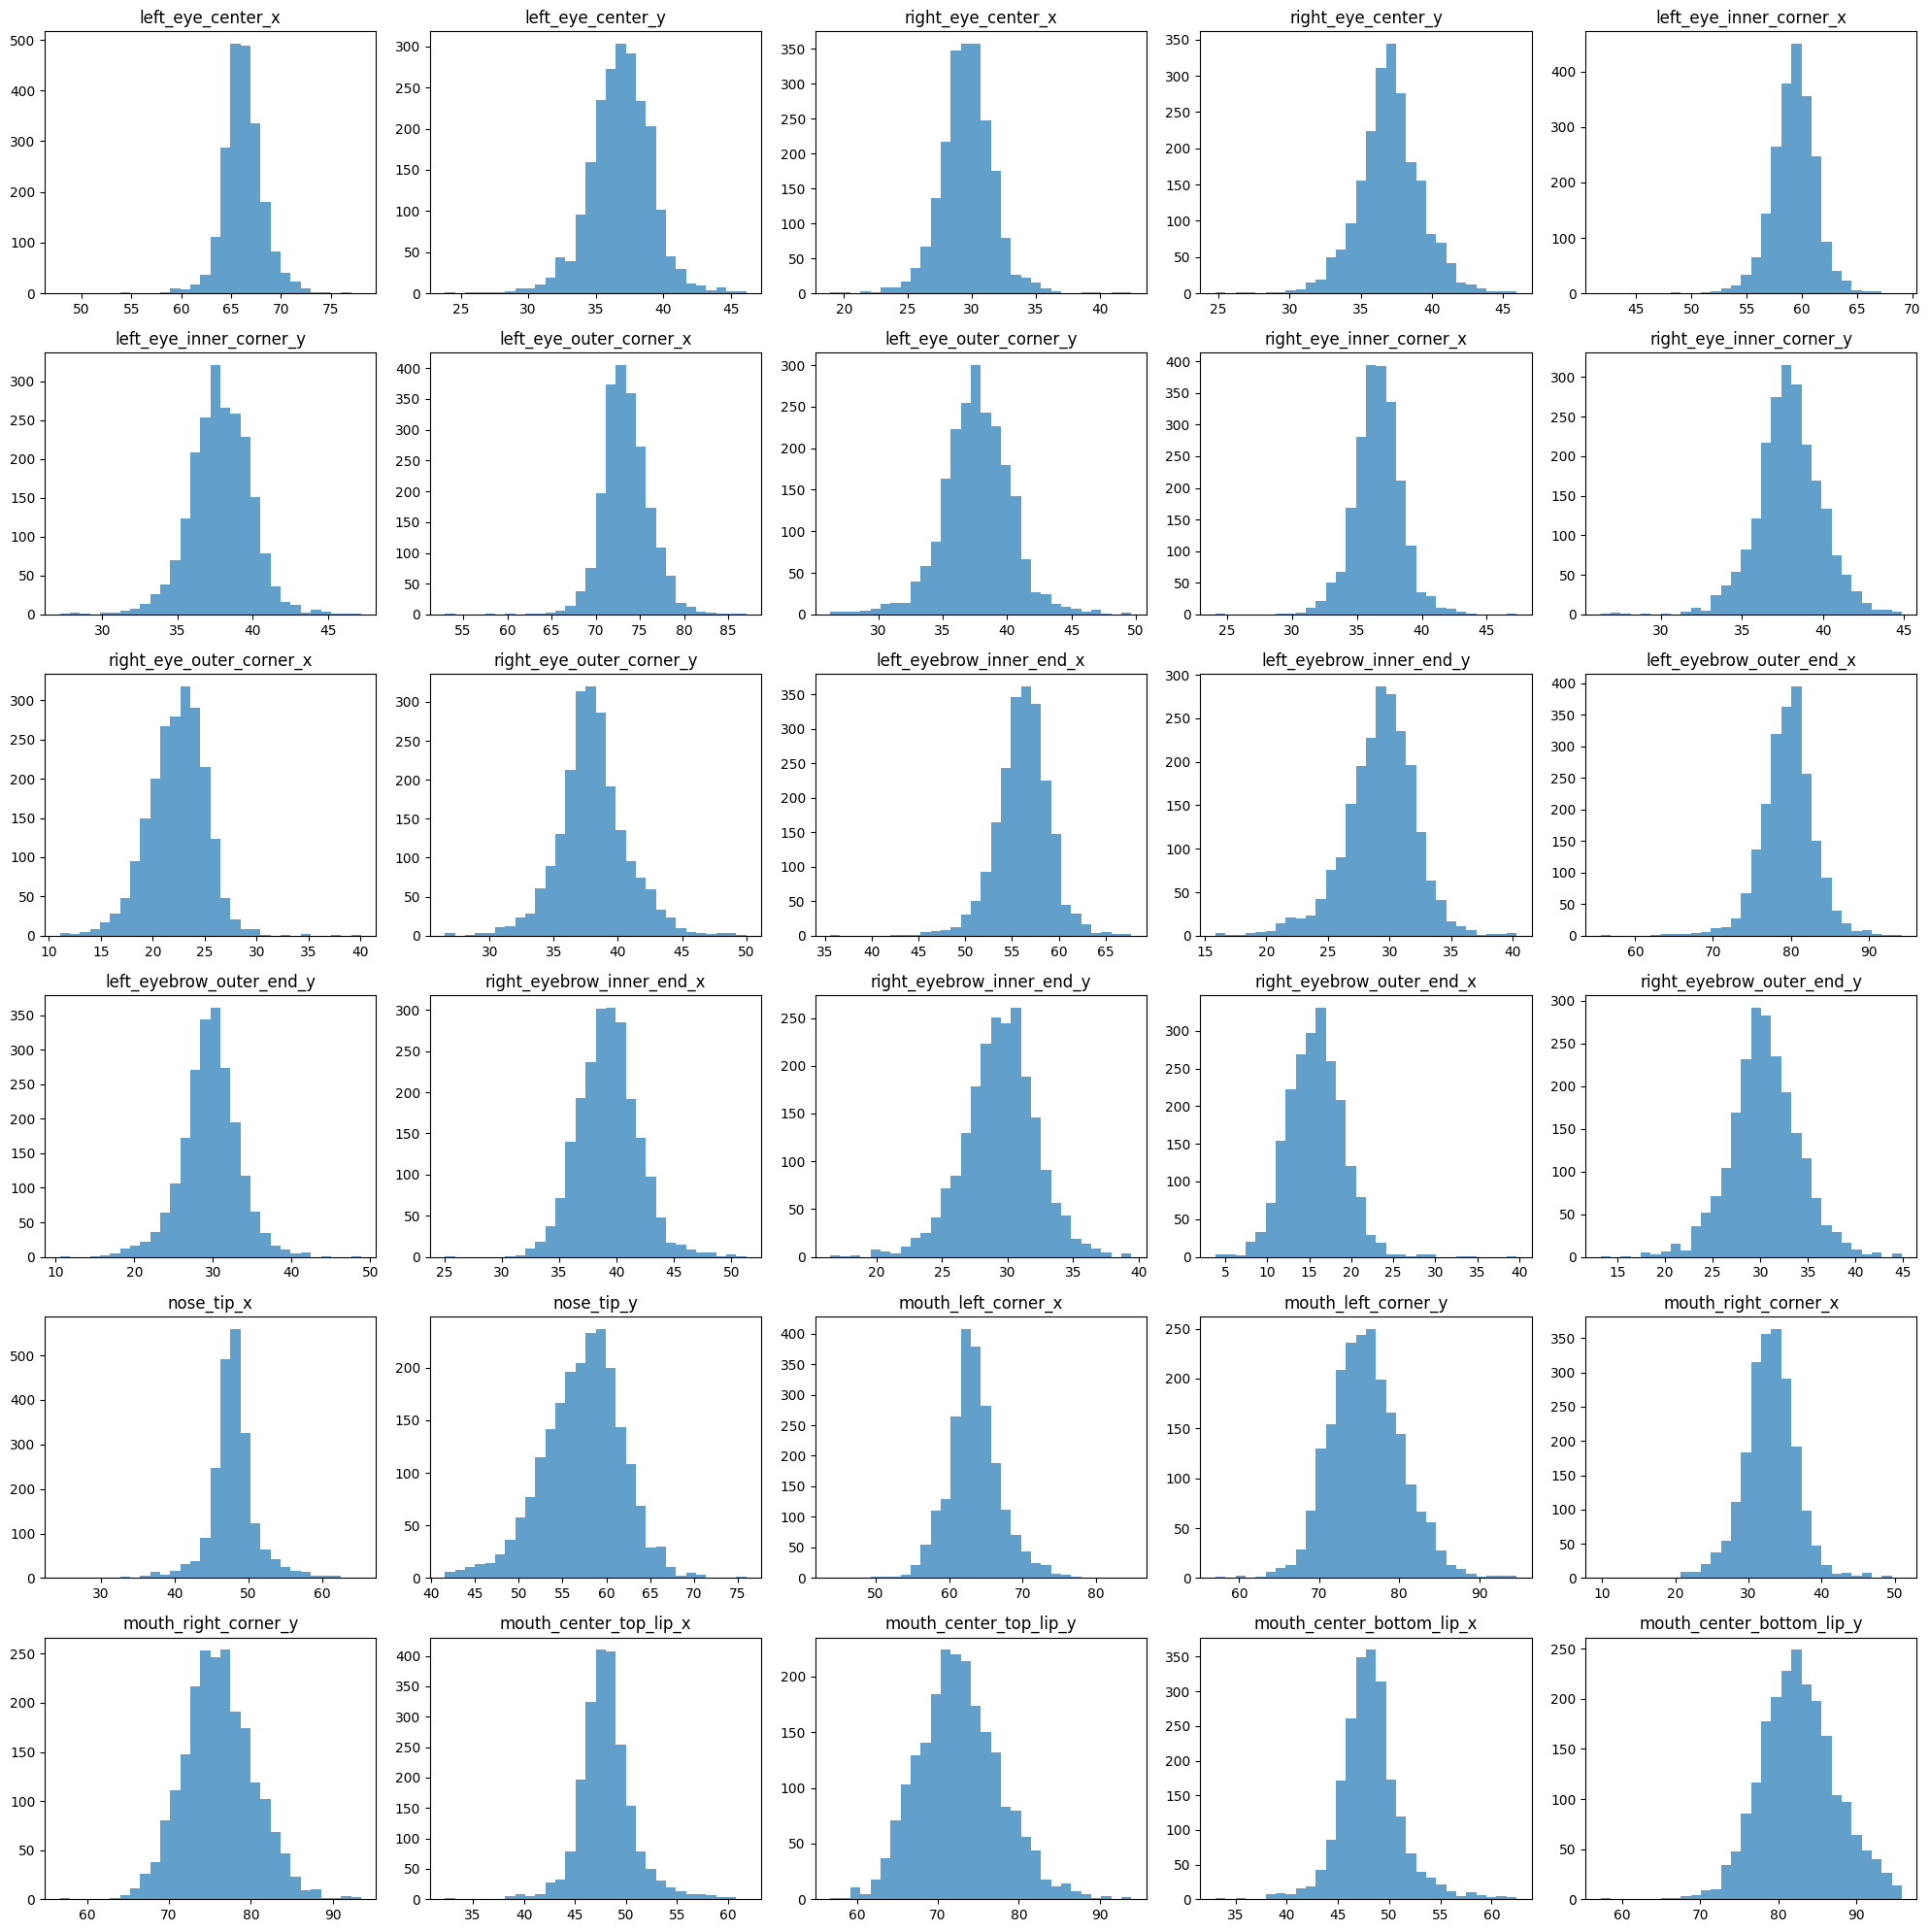

In [ ]:
numeric_cols = df_clean.drop(columns=["Image"])

numeric_cols.hist(
    figsize=(20, 20),
    bins=30,
    alpha=0.7,
    grid=False
)

plt.tight_layout()
plt.show()

In [17]:
def fill_missing_keypoints(df):
    """
    Fill missing facial keypoints.
    1. Use left/right symmetry when possible.
    2. Fill remaining NaN values with column median.
    3. Keep original dataframe unchanged.
    """

    df_filled = df.copy()

    # All keypoint columns except Image
    keypoint_cols = [col for col in df_filled.columns if col != "Image"]

    # Left-right symmetric keypoint pairs
    symmetric_pairs = [
        ("left_eye_center_x", "right_eye_center_x"),
        ("left_eye_center_y", "right_eye_center_y"),

        ("left_eye_inner_corner_x", "right_eye_inner_corner_x"),
        ("left_eye_inner_corner_y", "right_eye_inner_corner_y"),

        ("left_eye_outer_corner_x", "right_eye_outer_corner_x"),
        ("left_eye_outer_corner_y", "right_eye_outer_corner_y"),

        ("left_eyebrow_inner_end_x", "right_eyebrow_inner_end_x"),
        ("left_eyebrow_inner_end_y", "right_eyebrow_inner_end_y"),

        ("left_eyebrow_outer_end_x", "right_eyebrow_outer_end_x"),
        ("left_eyebrow_outer_end_y", "right_eyebrow_outer_end_y"),

        ("mouth_left_corner_x", "mouth_right_corner_x"),
        ("mouth_left_corner_y", "mouth_right_corner_y"),
    ]

    # Symmetry-based filling
    for left_col, right_col in symmetric_pairs:
        if left_col in df_filled.columns and right_col in df_filled.columns:
            df_filled[left_col] = df_filled[left_col].fillna(df_filled[right_col])
            df_filled[right_col] = df_filled[right_col].fillna(df_filled[left_col])

    # Fill remaining missing values with median
    for col in keypoint_cols:
        df_filled[col] = df_filled[col].fillna(df_filled[col].median())

    return df_filled

In [18]:
df_train = fill_missing_keypoints(df_train)

In [19]:
df_train.isnull().sum()

left_eye_center_x            0
left_eye_center_y            0
right_eye_center_x           0
right_eye_center_y           0
left_eye_inner_corner_x      0
left_eye_inner_corner_y      0
left_eye_outer_corner_x      0
left_eye_outer_corner_y      0
right_eye_inner_corner_x     0
right_eye_inner_corner_y     0
right_eye_outer_corner_x     0
right_eye_outer_corner_y     0
left_eyebrow_inner_end_x     0
left_eyebrow_inner_end_y     0
left_eyebrow_outer_end_x     0
left_eyebrow_outer_end_y     0
right_eyebrow_inner_end_x    0
right_eyebrow_inner_end_y    0
right_eyebrow_outer_end_x    0
right_eyebrow_outer_end_y    0
nose_tip_x                   0
nose_tip_y                   0
mouth_left_corner_x          0
mouth_left_corner_y          0
mouth_right_corner_x         0
mouth_right_corner_y         0
mouth_center_top_lip_x       0
mouth_center_top_lip_y       0
mouth_center_bottom_lip_x    0
mouth_center_bottom_lip_y    0
Image                        0
dtype: int64

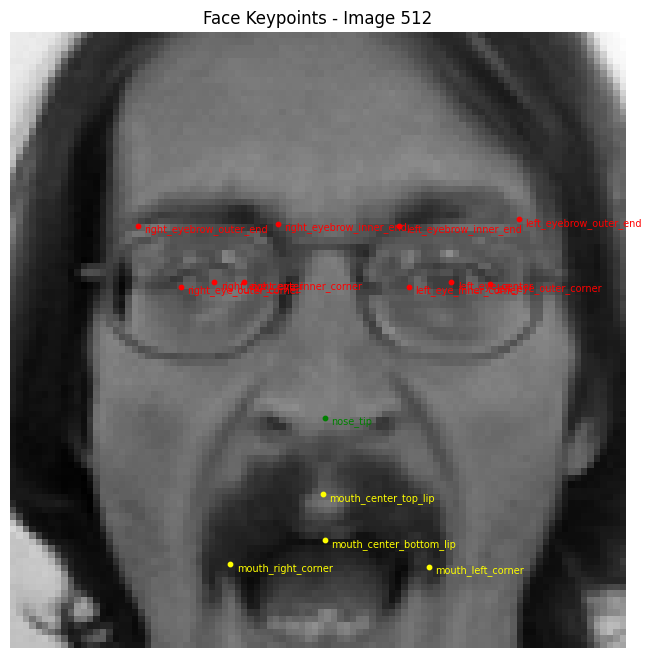

In [20]:
show_face_with_keypoints(df_train, 512)